# What is PCA?

Principal Component Analysis (PCA) is one of the most widely used dimensionality reduction techniques in Machine Learning.

Instead of increasing information,

PCA tries to **reduce the number of features** while preserving as much information as possible.

For example,

Instead of using

- Age
- Height
- Weight
- Attendance
- Assignment Marks
- Internal Marks
- Semester Marks
- Communication Skills
- Programming Score
- Aptitude

PCA may reduce them to only

- Principal Component 1
- Principal Component 2

while still preserving most of the original information.

# Why Do We Need PCA?

Modern datasets often contain a very large number of features.

For example,

A medical dataset may contain

- Blood Pressure
- Sugar Level
- Cholesterol
- BMI
- Age
- Heart Rate
- ECG Values
- Oxygen Level
- etc.

Having too many features creates several problems.

- More memory consumption.
- Slower model training.
- Difficult to visualize.
- Higher computational cost.
- Redundant information.
- Increased risk of overfitting.

This problem is known as the **Curse of Dimensionality**.

PCA helps solve this problem.

# Curse of Dimensionality

Imagine plotting data.

1 Feature - A line.

2 Features - A plane.

3 Features - A cube.

10 Features - Impossible to visualize.

100 Features - Very difficult to process.

PCA converts many features into a smaller number of meaningful features called **Principal Components**.

# What is the Main Idea Behind PCA?

Suppose we collect data about students.

| Study Hours | Marks |
|--------------|-------|
| 2 | 40 |
| 4 | 55 |
| 6 | 70 |
| 8 | 85 |

Notice that

As Study Hours increase,

Marks also increase.

Both features contain similar information.

Instead of storing both,

can we represent them using just one new feature?

This is exactly what PCA tries to achieve.

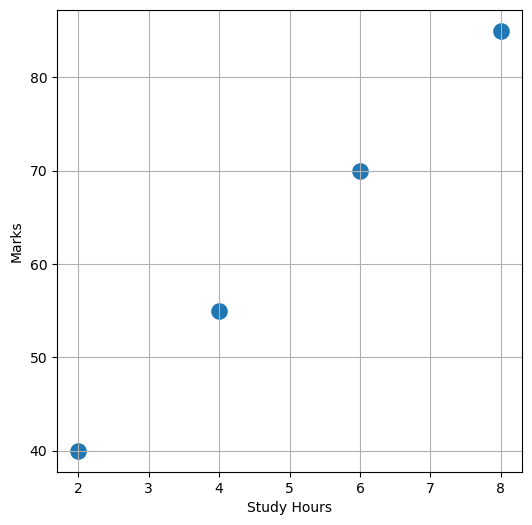

In [1]:
import numpy as np
import matplotlib.pyplot as plt

X = np.array([
    [2,40],
    [4,55],
    [6,70],
    [8,85]
])

plt.figure(figsize=(6,6))

plt.scatter(X[:,0],X[:,1],s=120)

plt.xlabel("Study Hours")
plt.ylabel("Marks")

plt.grid(True)

plt.show()

# Observation

The data points almost lie on a straight line.

This means Study Hours and Marks are strongly correlated. Instead of describing each student using

2 features, perhaps one feature is enough.

PCA discovers this automatically.

# What is Correlation?

Correlation tells us how strongly two features are related.

Positive Correlation  - As one feature increases, the other feature also increases.

Negative Correlation - As one feature increases, the other decreases.

No Correlation - The two features are unrelated.

PCA works best when features are correlated.

In [2]:
correlation=np.corrcoef(
    X[:,0],
    X[:,1]
)

print(correlation)

[[1. 1.]
 [1. 1.]]


# Observation

The correlation value is very close to +1, This means Study Hours and Marks

are strongly related. Therefore, one feature contains information about the other.

PCA can combine these features into a smaller number of Principal Components.

# What is a Principal Component?

A Principal Component is a new feature created from the original features.

Instead of using Study Hours and Marks PCA creates

Principal Component 1 (PC1)

Principal Component 2 (PC2)

The first Principal Component captures the maximum possible variation in the data.

The second Principal Component captures the remaining variation.

# Important Observation

PCA does not remove information randomly.

Instead, it keeps the directions that contain the maximum variation.

The direction with the highest variation becomes - Principal Component 1.

The second highest variation becomes - Principal Component 2.

This is why PCA preserves most of the useful information while reducing the number of features.

# Mathematics Behind PCA

##  Dataset

We will use a very small dataset containing only two features.

Feature 1 - Study Hours

Feature 2 - Marks

| Student | Study Hours | Marks |
|----------|-------------|-------|
| A | 2 | 40 |
| B | 4 | 55 |
| C | 6 | 70 |
| D | 8 | 85 |

Since there are only two features, it becomes easy to visualize every mathematical calculation.

In [3]:
import numpy as np

X = np.array([
    [2,40],
    [4,55],
    [6,70],
    [8,85]
])

print(X)

[[ 2 40]
 [ 4 55]
 [ 6 70]
 [ 8 85]]


# Step 1: Calculate the Mean

Before shifting data into principal components, the very first step in **Principal Component Analysis (PCA)** is calculating the **mean** ($\mu$) of every single feature (column) independently. 

Centering the data by calculating the mean allows us to shift the center of our entire dataset directly onto the origin $(0,0)$ of our graph later on.

---

### 1. Mean for Study Hours ($x$)
$$\mu_x = \frac{2 + 4 + 6 + 8}{4} = \frac{20}{4} = 5.0$$

### 2. Mean for Marks ($y$)
$$\mu_y = \frac{40 + 55 + 70 + 85}{4} = \frac{250}{4} = 62.5$$

---

### Conclusion:
Our dataset's average center point is located at **$(5.0, 62.5)$**. 

In the next step, we will subtract these mean values from every corresponding data point. This process is called **Mean Centering**, and it ensures that our data has a mean of exactly $0$ before we calculate variances and project our vectors!

In [4]:
mean = np.mean(X, axis=0)

print("Mean of Study Hours :", mean[0])
print("Mean of Marks       :", mean[1])

Mean of Study Hours : 5.0
Mean of Marks       : 62.5


# Why Do We Calculate the Mean?

Suppose we want to compare every student's study hours.

Instead of comparing with zero, it is more meaningful to compare each student with the average student.

Therefore, PCA shifts the origin to the center of the data.

This process is  **Mean Centering**.

# Step 2: Mean Centering

Once we have calculated the feature means ($\mu_x = 5.0$ and $\mu_y = 62.5$), we subtract the corresponding mean from **every single observation** in our dataset. 

This transformation shifts the coordinate system so that the exact center of our data points sits perfectly at the origin $(0, 0)$.

---

### Step-by-Step Transformation:

* **Student A:** $$\text{Study Hours: } 2 - 5.0 = -3.0$$
  $$\text{Marks: } 40 - 62.5 = -22.5$$
  New Coordinates: $(-3.0, -22.5)$

* **Student B:** $$\text{Study Hours: } 4 - 5.0 = -1.0$$
  $$\text{Marks: } 55 - 62.5 = -7.5$$
  New Coordinates: $(-1.0, -7.5)$

* **Student C:** $$\text{Study Hours: } 6 - 5.0 = 1.0$$
  $$\text{Marks: } 70 - 62.5 = 7.5$$
  New Coordinates: $(1.0, 7.5)$

* **Student D:** $$\text{Study Hours: } 8 - 5.0 = 3.0$$
  $$\text{Marks: } 85 - 62.5 = 22.5$$
  New Coordinates: $(3.0, 22.5)$

---

### The Centered Data Matrix:
Our transformed dataset now looks like this:

| Student | Centered Study Hours ($x - \mu_x$) | Centered Marks ($y - \mu_y$) |
| :--- | :--- | :--- |
| **A** | -3.0 | -22.5 |
| **B** | -1.0 | -7.5 |
| **C** | 1.0 | 7.5 |
| **D** | 3.0 | 22.5 |

---

Notice how the signs changed! Points that were below average now have **negative** values, and points that were above average have **positive** values. If you sum up all the values in either of these columns now, the total will be exactly **0**. This zero-mean state is mandatory before we compute the covariance matrix in the next step.

In [5]:
centered = X - mean

print(centered)

[[ -3.  -22.5]
 [ -1.   -7.5]
 [  1.    7.5]
 [  3.   22.5]]


# Step 3: Variance

Variance measures **how much a single feature varies from its mean.**

* **Large Variance** $\rightarrow$ Large spread (data points are highly scattered)
* **Small Variance** $\rightarrow$ Small spread (data points are tightly packed around the mean)



---

### The Mathematical Formula:
The sample variance ($s^2$) of a feature is calculated as:

$$\text{Variance} = \frac{\sum(x - \mu)^2}{n - 1}$$

where:
* **$x$** = Individual centered observation values for that feature.
* **$\mu$** = The calculated mean of the feature (which is $0$ if you already performed mean-centering).
* **$n$** = The total number of observations (data points) in the dataset.
* **$n - 1$** = Bessel's correction, used for sample datasets to ensure an unbiased estimation.

---

## 1. Variance of Study Hours

The centered Study Hours values are

$$
[-3,\,-1,\,+1,\,+3]
$$

Now square every value.

| Centered Value | Square |
|---------------|---------|
| -3 | 9 |
| -1 | 1 |
| 1 | 1 |
| 3 | 9 |

Sum of Squares

$$
9+1+1+9=20
$$

Therefore,

$$
Variance_x=
\frac{20}{3}
=
6.67
$$

## 2. Variance of Marks

Centered Marks

$$
[-22.5,\,-7.5,\,+7.5,\,+22.5]
$$

Square every value.

| Centered Value | Square |
|---------------|---------|
| -22.5 | 506.25 |
| -7.5 | 56.25 |
| 7.5 | 56.25 |
| 22.5 | 506.25 |

Sum

$$
506.25+56.25+56.25+506.25
=
1125
$$

Therefore,

$$
Variance_y=
\frac{1125}{3}
=
375
$$

# Step 4: Calculate the Covariance

Variance tells us **how one feature varies**.

Covariance tells us **how two features vary together**.

It measures whether two features

- Increase together (Positive Covariance)
- Decrease together (Negative Covariance)
- Are unrelated (Covariance ≈ 0)

Since PCA tries to find relationships between different features, **Covariance is one of the most important calculations in PCA.**

---

## Covariance Formula

For two features \(X\) and \(Y\),

$$
Cov(X,Y)=
\frac{\sum (x-\mu_x)(y-\mu_y)}
{n-1}
$$

## Step 1: Multiply the Centered Values

| Centered Study Hours | Centered Marks | Product |
|----------------------|----------------|---------|
| -3 | -22.5 | 67.5 |
| -1 | -7.5 | 7.5 |
| 1 | 7.5 | 7.5 |
| 3 | 22.5 | 67.5 |

Sum of Products

$$
67.5+7.5+7.5+67.5
=
150
$$

## Step 2: Calculate Covariance

Substitute into the formula.

$$
Cov(X,Y)
=
\frac{150}{3}
$$

Therefore,

$$
Cov(X,Y)=50
$$

## Since Covariance is Symmetric

The covariance between

Study Hours and Marks

is the same as

Marks and Study Hours.

Therefore,

$$
Cov(X,Y)=Cov(Y,X)=50
$$

# Step 4: Construct the Covariance Matrix

The covariance matrix is

$$
\Sigma=
\begin{bmatrix}
Variance_x & Cov(X,Y)\\
Cov(Y,X) & Variance_y
\end{bmatrix}
$$

Substituting our values,

$$
\Sigma=
\begin{bmatrix}
6.67 & 50\\
50 & 375
\end{bmatrix}
$$

# Interpretation of the Covariance Matrix

$$
\Sigma=
\begin{bmatrix}
6.67 & 50\\
50 & 375
\end{bmatrix}
$$

The diagonal elements represent the **variance** of each feature.

$$
6.67
$$

Variance of Study Hours

$$
375
$$

Variance of Marks

The off-diagonal elements represent the **covariance**.

$$
50
$$

Since the covariance is **positive**, it tells us that

- Students who study more tend to score higher marks.
- Both features increase together.
- The features are strongly correlated.

This is exactly the type of relationship that PCA tries to capture.

# Eigenvalue Equation

The eigenvalues are obtained using the equation

$$
|A-\lambda I|=0
$$

where

- \(A\) = Covariance Matrix
- \(I\) = Identity Matrix
- \(\lambda\) = Eigenvalue

Substituting our covariance matrix,

$$
\left|
\begin{bmatrix}
6.67 & 50\\
50 & 375
\end{bmatrix}
-
\lambda
\begin{bmatrix}
1&0\\
0&1
\end{bmatrix}
\right|
=0
$$

# Step 2: Subtract λ from the Diagonal

Subtract λ only from the diagonal elements.

$$
\left|
\begin{matrix}
6.67-\lambda & 50\\
50 & 375-\lambda
\end{matrix}
\right|
=0
$$

Now calculate the determinant.

# Step 3: Expand the Determinant

For a 2×2 matrix,

$$
\left|
\begin{matrix}
a&b\\
c&d
\end{matrix}
\right|
=
ad-bc
$$

Applying this formula,

$$
(6.67-\lambda)(375-\lambda)
-
(50)(50)
=
0
$$

# Step 4: Expand the Equation

Expanding,

$$
2501.25
-
381.67\lambda
+
\lambda^2
-
2500
=
0
$$

Simplifying,

$$
\lambda^2
-
381.67\lambda
+
1.25
=
0
$$

This is called the **Characteristic Equation**.

# Step 5: Solve the Characteristic Equation

Using the quadratic formula,

$$
\lambda=
\frac{-b\pm\sqrt{b^2-4ac}}
{2a}
$$

The two eigenvalues are approximately

$$
\lambda_1
=
381.66
$$

$$
\lambda_2
=
0.003
$$

Notice that

The first eigenvalue is much larger than the second.

# Interpretation of Eigenvalues

The eigenvalue tells us

**how much variance exists along its corresponding eigenvector.**

Large Eigenvalue

↓

Large amount of information

Small Eigenvalue

↓

Very little information

Therefore,

the eigenvector corresponding to the largest eigenvalue becomes the

**First Principal Component (PC1).**

# Step 6: Calculate the Eigenvector

To calculate the eigenvector,

we substitute the eigenvalue into

$$
(A-\lambda I)\mathbf{v}=0
$$

where

- \(A\) = Covariance Matrix
- \(\lambda\) = Eigenvalue
- \(\mathbf{v}\) = Eigenvector

$$
\left(
\begin{bmatrix}
6.67&50\\
50&375
\end{bmatrix}
-
381.66
\begin{bmatrix}
1&0\\
0&1
\end{bmatrix}
\right)
\begin{bmatrix}
x\\
y
\end{bmatrix}
=
\begin{bmatrix}
0\\
0
\end{bmatrix}
$$

$$
\begin{bmatrix}
-374.99&50\\
50&-6.66
\end{bmatrix}
\begin{bmatrix}
x\\
y
\end{bmatrix}
=
\begin{bmatrix}
0\\
0
\end{bmatrix}
$$

$$
-374.99x+50y=0
$$

$$
50x-6.66y=0
$$

$$
-374.99x+50y=0
$$

Move one term to the other side.

$$
50y=374.99x
$$

Divide by 50.

$$
y=7.4998x
$$

Since only the direction matters, use x = 1

$$
\mathbf{v}
=
\begin{bmatrix}
1\\
7.4998
\end{bmatrix}
$$

Normalize the Eigenvector Because PCA always uses a unit vector (length = 1).

sqrt(1 **2 + 7.4998 **2)

$$
||v||
=
\sqrt{57.247}
=
7.566
$$

Divide every element by the length.

$$
\mathbf{v}
=
\frac1{7.566}
\begin{bmatrix}
1\\
7.4998
\end{bmatrix}
$$

$$
\mathbf{v1}
=
\begin{bmatrix}
0.132\\
0.991
\end{bmatrix}
$$

calculate for Second Eigenvalue λ2​=0.003 also the result will be 
$$
\mathbf{v2}
=
\begin{bmatrix}
0.991\\
-0.132
\end{bmatrix}
$$

In [8]:
import numpy as np

covariance = np.array([
    [6.67,50],
    [50,375]
])

eigenvalues,eigenvectors = np.linalg.eig(covariance)

print("Eigenvalues\n")
print(eigenvalues)

print("\nEigenvectors\n")
print(eigenvectors)

Eigenvalues

[3.27510867e-03 3.81666725e+02]

Eigenvectors

[[-0.99122775 -0.13216485]
 [ 0.13216485 -0.99122775]]


In [9]:
import numpy as np
from sklearn.decomposition import PCA

# Example: 100 samples, 5 features
X = np.random.rand(100, 5)

print("Original Shape:", X.shape)

pca = PCA(n_components=2)

X_new = pca.fit_transform(X)

print("Reduced Shape:", X_new.shape)

Original Shape: (100, 5)
Reduced Shape: (100, 2)


In [10]:
print(pca.explained_variance_ratio_)

[0.2649846 0.2327003]


New Feature after PCA are
PC1 = V1 * X1
PC2 = V2 * Y1 

| Algorithm Type          | Use PCA?     |
| ----------------------- | ------------ |
| KNN                     | ✅ Yes        |
| K-Means                 | ✅ Yes        |
| Hierarchical Clustering | ✅ Yes        |
| DBSCAN                  | ✅ Yes        |
| SVM                     | ✅ Often      |
| Logistic Regression     | ⚠️ Sometimes |
| Linear Regression       | ⚠️ Sometimes |
| Neural Networks         | ⚠️ Sometimes |
| Decision Tree           | ❌ No         |
| Random Forest           | ❌ No         |
| XGBoost                 | ❌ No         |


| Sample | X₁ | X₂ | X₃ |
| ------ | -: | -: | -: |
| A      |  2 |  3 |  4 |
| B      |  4 |  5 |  6 |
| C      |  6 |  7 |  8 |
| D      |  8 |  9 | 10 |


Original Data

      4 × 3

        │
        ▼

Standardize Data

      4 × 3

        │
        ▼

Covariance Matrix

      3 × 3

        │
        ▼

Eigenvalues
Eigenvectors

        │
        ▼

Select Top 2 Eigenvectors

      3 × 2

        │
        ▼

Multiply

(4 × 3) × (3 × 2)

        │
        ▼

Principal Components

      4 × 2